In [13]:
!pip install openpyxl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
print(os.getcwd())









[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
# Load all sheets
xls = pd.ExcelFile(r"C:\Users\yasha\Downloads\startup_model.xlsx")
assumptions = pd.read_excel(xls, sheet_name="assumptions")
monthly_projection = pd.read_excel(xls, sheet_name="monthly_projection")
cash_flow = pd.read_excel(xls, sheet_name="cash_flow")
KPI_summary = pd.read_excel(xls, sheet_name="KPI_summary")
# See first 5 rows of Assumptions
print("assumptions Sheet:")
print(assumptions.head())

# Monthly Projection
print("\nmonthly projection Sheet:")
print(monthly_projection.head())

# Cash Flow
print("\ncash flow Sheet:")
print(cash_flow.head())

# KPI Summary
print("\nKPI summary Sheet:")
print(KPI_summary.head())



assumptions Sheet:
           starting_customers       1000
0                        ARPU     499.00
1         Monthly_growth_rate       0.08
2          Monthly_churn_rate       0.04
3  variable_cost_per_customer      80.00
4          fixed_monthly_cost  450000.00

monthly projection Sheet:
     Month  Customers  Revenue  Variable_cost  Fixed_cost  Total_cost  Profit
0  month 1       1000   499000          80000      450000      530000  -31000
1  month 2       1040   518960          83200      450000      533200  -14240
2  month 3       1081   539419          86480      450000      536480    2939
3  month 4       1124   560876          89920      450000      539920   20956
4  month 5       1168   582832          93440      450000      543440   39392

cash flow Sheet:
     Month  Opening_cash  Profit  Funding  Closing_cash Runway_flag
0  month 1       2500000  -31000        0       2469000       Alive
1  month 2       2469000  -14240        0       2454760       Alive
2  month 3       2

In [15]:
def run_scenario(starting_customers, growth_rate, churn_rate, arpu, var_cost, fixed_cost, opening_cash, months=24):
    # Lists to store monthly values
    customers_list = []
    revenue_list = []
    var_cost_list = []
    fixed_cost_list = []
    profit_list = []
    closing_cash_list = []

    # Initialize
    customers = starting_customers
    cash = opening_cash

    for m in range(months):
        # Customer growth
        customers = max(0, int(customers * (1 + growth_rate - churn_rate)))
        customers_list.append(customers)

        # Revenue
        revenue = customers * arpu
        revenue_list.append(revenue)

        # Costs
        var_cost_total = customers * var_cost
        var_cost_list.append(var_cost_total)
        fixed_cost_list.append(fixed_cost)

        # Profit
        profit = revenue - (var_cost_total + fixed_cost)
        profit_list.append(profit)

        # Cash Flow
        cash = cash + profit
        closing_cash_list.append(cash)

    # Return results as DataFrame
    return pd.DataFrame({
        "Month": range(1, months+1),
        "Customers": customers_list,
        "Revenue": revenue_list,
        "Variable_Cost": var_cost_list,
        "Fixed_Cost": fixed_cost_list,
        "Profit": profit_list,
        "Closing_Cash": closing_cash_list
    })


In [37]:
finance_df = run_scenario(
    starting_customers = assumptions.iloc[0, 1],
    growth_rate = 0.08,
    churn_rate = 0.04,
    arpu = 499,
    var_cost = 80,
    fixed_cost = 450000,
    opening_cash = assumptions.iloc[5, 1],
    months=24
)
print(finance_df)


    Month  Customers  Revenue  Variable_Cost  Fixed_Cost  Profit  Closing_Cash
0       1        518   258482          41440      450000 -232958     2267042.0
1       2        538   268462          43040      450000 -224578     2042464.0
2       3        559   278941          44720      450000 -215779     1826685.0
3       4        581   289919          46480      450000 -206561     1620124.0
4       5        604   301396          48320      450000 -196924     1423200.0
5       6        628   313372          50240      450000 -186868     1236332.0
6       7        653   325847          52240      450000 -176393     1059939.0
7       8        679   338821          54320      450000 -165499      894440.0
8       9        706   352294          56480      450000 -154186      740254.0
9      10        734   366266          58720      450000 -142454      597800.0
10     11        763   380737          61040      450000 -130303      467497.0
11     12        793   395707          63440      45

In [40]:
finance_df = pd.concat(
    [df.assign(Scenario=name) for name, df in results.items()],
    ignore_index=True
)
finance_df.to_excel("Finance_Output.xlsx", index=False)


In [28]:
scenarios = {
    "Base Case": {"growth_rate": 0.08, "churn_rate": 0.04, "arpu": 499, "var_cost": 80, "fixed_cost": 450000},
    "Best Case": {"growth_rate": 0.10, "churn_rate": 0.03, "arpu": 550, "var_cost": 70, "fixed_cost": 420000},
    "Worst Case": {"growth_rate": 0.05, "churn_rate": 0.06, "arpu": 450, "var_cost": 100, "fixed_cost": 500000}
}

results = {}

for name, params in scenarios.items():
    results[name] = run_scenario(
        starting_customers = assumptions.iloc[0, 1],
        growth_rate = params["growth_rate"],
        churn_rate = params["churn_rate"],
        arpu = params["arpu"],
        var_cost = params["var_cost"],
        fixed_cost = params["fixed_cost"],
        opening_cash = assumptions.iloc[5, 1],
        months=24
    )


In [19]:
compare_cash = pd.DataFrame({name: df["Closing_Cash"] for name, df in results.items()})
compare_cash.index = range(1, 25)  # Month numbers
print(compare_cash)


Empty DataFrame
Columns: []
Index: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]


In [29]:
# Create a comparison DataFrame for Closing Cash
compare_cash = pd.DataFrame({name: df["Closing_Cash"] for name, df in results.items()})
compare_cash.index = range(1, 25)  # Month numbers
print(compare_cash)



    Base Case  Best Case  Worst Case
1   2267042.0  2335840.0   2172900.0
2   2042464.0  2189440.0   1844050.0
3   1826685.0  2061760.0   1513450.0
4   1620124.0  1954240.0   1181100.0
5   1423200.0  1868320.0    847000.0
6   1236332.0  1805440.0    511150.0
7   1059939.0  1767520.0    173550.0
8    894440.0  1756000.0   -165800.0
9    740254.0  1772800.0   -506900.0
10   597800.0  1819840.0   -849750.0
11   467497.0  1899520.0  -1194350.0
12   349764.0  2013760.0  -1540700.0
13   245020.0  2164960.0  -1888800.0
14   153684.0  2356000.0  -2238650.0
15    76594.0  2589760.0  -2590250.0
16    14169.0  2869120.0  -2943600.0
17   -32753.0  3196960.0  -3298700.0
18   -63753.0  3577120.0  -3655550.0
19   -77993.0  4012960.0  -4014150.0
20   -75054.0  4508320.0  -4374500.0
21   -54098.0  5067520.0  -4736250.0
22   -14706.0  5694880.0  -5099400.0
23    43960.0  6395200.0  -5463950.0
24   122738.0  7173760.0  -5829900.0


In [32]:
compare_profit = pd.DataFrame({name: df["Profit"] for name, df in results.items()})
compare_profit.index = range(1, 25)


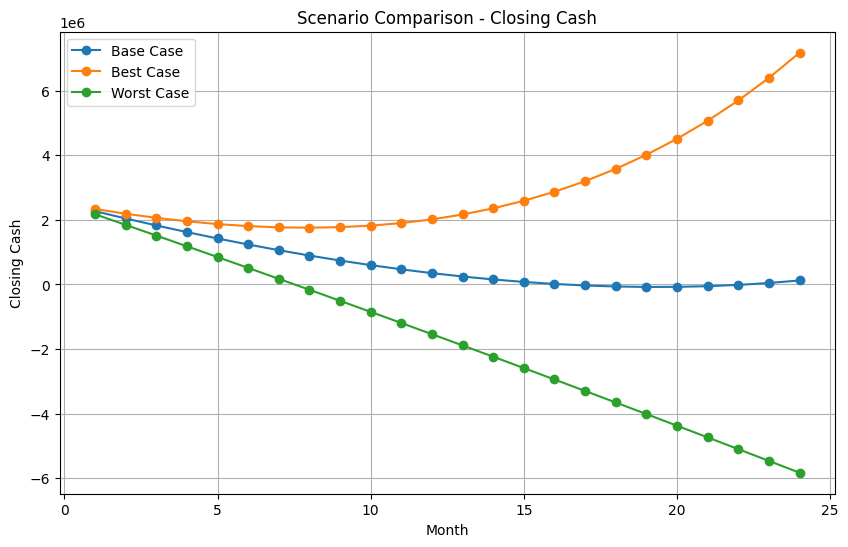

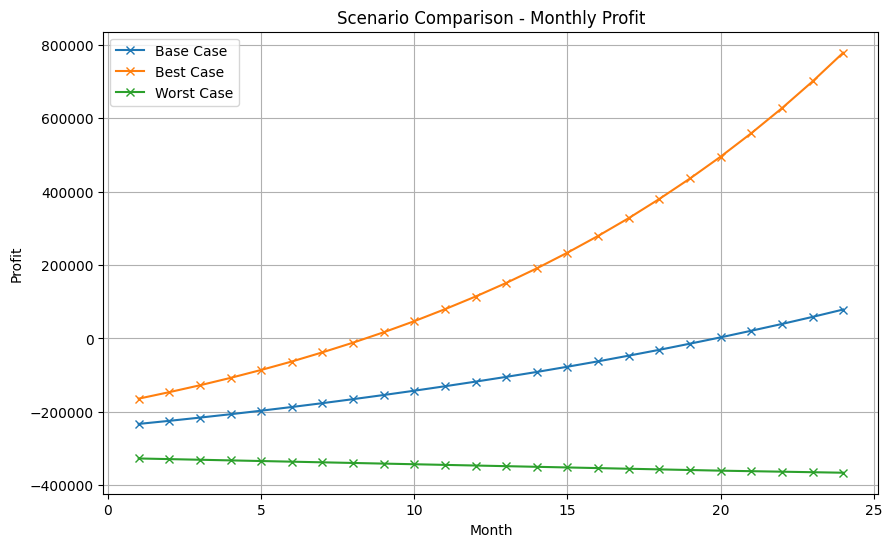

In [33]:
import matplotlib.pyplot as plt

# Cash Flow Comparison
compare_cash.plot(figsize=(10,6), marker='o')
plt.title("Scenario Comparison - Closing Cash")
plt.xlabel("Month")
plt.ylabel("Closing Cash")
plt.grid(True)
plt.show()

# Profit Comparison
compare_profit.plot(figsize=(10,6), marker='x')
plt.title("Scenario Comparison - Monthly Profit")
plt.xlabel("Month")
plt.ylabel("Profit")
plt.grid(True)
plt.show()


In [34]:
with pd.ExcelWriter("Scenario_Results.xlsx") as writer:
    for name, df in results.items():
        df.to_excel(writer, sheet_name=name, index=False)
    compare_cash.to_excel(writer, sheet_name="Cash_Comparison", index_label="Month")
    compare_profit.to_excel(writer, sheet_name="Profit_Comparison", index_label="Month")


In [35]:
import os
print(os.getcwd())


C:\Users\yasha
